In [1]:
%%capture
!pip install -q torch_geometric
print('Done')

In [3]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

# Fix all random seeds so our results are reproducable when re-run

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Imports are OK. Pytorch Version:', torch.__version__)

Imports are OK. Pytorch Version: 2.11.0+cu128


In [4]:
geno_DIR = '/content/drive/MyDrive/GNN/mdp_numeric.txt'
pheno_DIR = '/content/drive/MyDrive/GNN/mdp_traits.txt'
kns_DIR = '/content/drive/MyDrive/GNN/KSN.txt'
SNP_DIR = '/content/drive/MyDrive/GNN/mdp_SNP_information.txt'

In [5]:
# ============================================================
# Cell: Copy the Drive files into the notebook's working directory
# ============================================================
import os
import shutil

DATA_DIR = "gapit_data"
os.makedirs(DATA_DIR, exist_ok=True)

drive_paths = {
    "mdp_numeric.txt": geno_DIR,
    "mdp_traits.txt": pheno_DIR,
    "KSN.txt": kns_DIR,
    "mdp_SNP_information.txt": SNP_DIR,
}

for target_name, source_path in drive_paths.items():
    shutil.copy(source_path, os.path.join(DATA_DIR, target_name))

print("Copied files from Drive into:", os.path.abspath(DATA_DIR))
print(os.listdir(DATA_DIR))

Copied files from Drive into: /content/gapit_data
['KSN.txt', 'mdp_numeric.txt', 'mdp_SNP_information.txt', 'mdp_traits.txt']


In [6]:

# ============================================================
# Cell: Load the three core files with pandas
# ============================================================

# --- Genotype matrix: rows = maize lines ("taxa"), columns = SNP markers ---
# Values are 0, 1, or 2: the count of the minor allele at that marker.
geno_df = pd.read_csv(os.path.join(DATA_DIR, "mdp_numeric.txt"), sep="\t")
geno_df = geno_df.set_index("taxa")   # use the line name as the row index
print("Genotype matrix shape (lines x SNPs):", geno_df.shape)
geno_df.iloc[:5, :6]

Genotype matrix shape (lines x SNPs): (281, 3093)


,PZB00859.1,PZA01271.1,PZA03613.2,PZA03613.1,PZA03614.2,PZA03614.1
taxa,,,,,,
33-16,2,0,0,2,2,2
38-11,2,2,0,2,2,2
4226,2,0,0,2,2,2
4722,2,2,0,2,2,2
A188,0,0,0,2,2,2


In [7]:
# --- Phenotypes (the traits we want to predict) ---
traits_df = pd.read_csv(os.path.join(DATA_DIR, "mdp_traits.txt"), sep="\t")
traits_df = traits_df.set_index("Taxa")
print("Traits table shape:", traits_df.shape)
print("\nHow many values are missing per trait?")
print(traits_df.isna().sum())
traits_df.head()

Traits table shape: (301, 3)

How many values are missing per trait?
EarHT      2
dpoll      4
EarDia    35
dtype: int64


,EarHT,dpoll,EarDia
Taxa,,,
811,59.50,NaN,NaN
4226,65.50,59.5,32.21933
4722,81.13,71.5,32.42100
33-16,64.75,64.5,NaN
38-11,92.25,68.5,37.89700


In [8]:
# --- Kinship (genetic relatedness) matrix ---
# This file has NO header row. The first column is the line name, and the
# remaining N columns are the kinship values against every one of the N lines
# (in the same order), so it is an N x N symmetric matrix with names attached.
ksn_raw = pd.read_csv(os.path.join(DATA_DIR, "KSN.txt"), sep="\t", header=None)
ksn_names = ksn_raw.iloc[:, 0].astype(str).tolist()
kinship_df = pd.DataFrame(
    ksn_raw.iloc[:, 1:].values,
    index=ksn_names,
    columns=ksn_names,
)
print("Kinship matrix shape:", kinship_df.shape)
print("Is it symmetric?", np.allclose(kinship_df.values, kinship_df.values.T))
print("Diagonal (self-relatedness) values, e.g. line 1:", kinship_df.values.diagonal()[0])
kinship_df.iloc[:5, :5]

Kinship matrix shape: (264, 264)
Is it symmetric? True
Diagonal (self-relatedness) values, e.g. line 1: 2.0


,33-16,38-11,4226,4722,A188
33-16,2.000000,0.228837,0.229322,0.268842,0.237145
38-11,0.228837,2.000000,0.244965,0.293708,0.175211
4226,0.229322,0.244965,2.000000,0.214859,0.236153
4722,0.268842,0.293708,0.214859,2.000000,0.259350
A188,0.237145,0.175211,0.236153,0.259350,2.000000


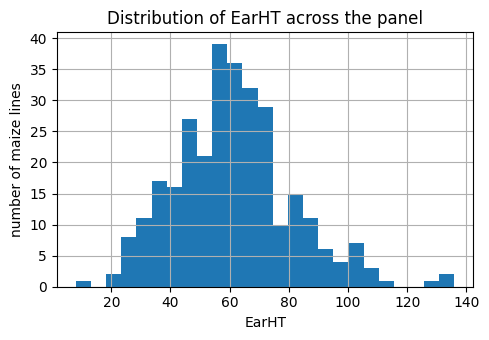

In [10]:
 #--- Quick sanity-check plot: distribution of the trait we'll predict ---
TARGET_TRAIT = "EarHT"   # Ear height in cm. Try "dpoll" (days to pollination) too!

plt.figure(figsize=(5, 3.5))
traits_df[TARGET_TRAIT].dropna().hist(bins=25)
plt.xlabel(f"{TARGET_TRAIT}")
plt.ylabel("number of maize lines")
plt.title(f"Distribution of {TARGET_TRAIT} across the panel")
plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# Cell: Find the common set of individuals and build aligned arrays
# ============================================================

common_lines = [
    name for name in ksn_names
    if name in geno_df.index
    and name in traits_df.index
    and pd.notna(traits_df.loc[name, TARGET_TRAIT])
]
print(f"Individuals present in genotype + kinship + trait ({TARGET_TRAIT}): "
      f"{len(common_lines)}")

# Reorder every table to follow this exact same list of individuals, so that
# row i in every array below always refers to the SAME maize line.
genotypes = geno_df.loc[common_lines].values.astype(np.float32)          # (N, num_SNPs)
phenotype = traits_df.loc[common_lines, TARGET_TRAIT].values.astype(np.float32)  # (N,)
kinship   = kinship_df.loc[common_lines, common_lines].values.astype(np.float32) # (N, N)

N = len(common_lines)
print("genotypes:", genotypes.shape, " phenotype:", phenotype.shape, " kinship:", kinship.shape)


Individuals present in genotype + kinship + trait (EarHT): 264
genotypes: (264, 3093)  phenotype: (264,)  kinship: (264, 264)


In [51]:
# ============================================================
# Cell: Standardize + PCA-reduce the SNP matrix -> node features
# ============================================================
N_COMPONENTS = 20  # how many principal components to keep as node features

# First, split individuals into train / validation / test BEFORE fitting the
# scaler and PCA. This avoids "data leakage": if we let the PCA see the test
# set while deciding which directions of genetic variation matter most, our
# reported accuracy would be optimistic and not trustworthy.
indices = np.arange(N)
rng = np.random.RandomState(SEED)
rng.shuffle(indices)

n_train = int(0.70 * N)
n_val   = int(0.15 * N)
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]
print(f"train / val / test sizes: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

# StandardScaler: makes every SNP column have mean 0, std 1, so no single
# marker dominates just because of its numeric scale.
scaler = StandardScaler().fit(genotypes[train_idx])
genotypes_scaled = scaler.transform(genotypes)

# PCA: fit only on the training individuals, then apply to everyone.
pca = PCA(n_components=N_COMPONENTS, random_state=SEED).fit(genotypes_scaled[train_idx])
node_features = pca.transform(genotypes_scaled)   # shape: (N, N_COMPONENTS)

print("Node feature matrix shape:", node_features.shape)
print(f"Variance explained by these {N_COMPONENTS} components: "
      f"{pca.explained_variance_ratio_.sum():.1%}")


train / val / test sizes: 184 / 39 / 41
Node feature matrix shape: (264, 20)
Variance explained by these 20 components: 32.8%


In [52]:
# ============================================================
# Cell: Build a k-nearest-relative graph from the kinship matrix
# ============================================================
K_NEIGHBORS = 8  # how many closest relatives each line connects to

kinship_no_self = kinship.copy()
np.fill_diagonal(kinship_no_self, -np.inf)  # never connect a node to itself

edge_src, edge_dst, edge_weight_list = [], [], []
for i in range(N):
    # indices of the K_NEIGHBORS most-related *other* lines to line i
    top_k = np.argsort(kinship_no_self[i])[-K_NEIGHBORS:]
    for j in top_k:
        # add the edge in BOTH directions: GNN message passing needs an
        # explicit edge for every direction information should flow.
        edge_src.append(i); edge_dst.append(j); edge_weight_list.append(kinship[i, j])
        edge_src.append(j); edge_dst.append(i); edge_weight_list.append(kinship[i, j])

# PyTorch Geometric expects edges as a (2, num_edges) tensor:
# row 0 = source node indices, row 1 = destination node indices.
edge_index  = torch.tensor([edge_src, edge_dst], dtype=torch.long)
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float32)

print("Number of directed edges (each undirected relation counted twice):", edge_index.shape[1])
print("Average number of relatives per line:", edge_index.shape[1] / N)


Number of directed edges (each undirected relation counted twice): 4224
Average number of relatives per line: 16.0


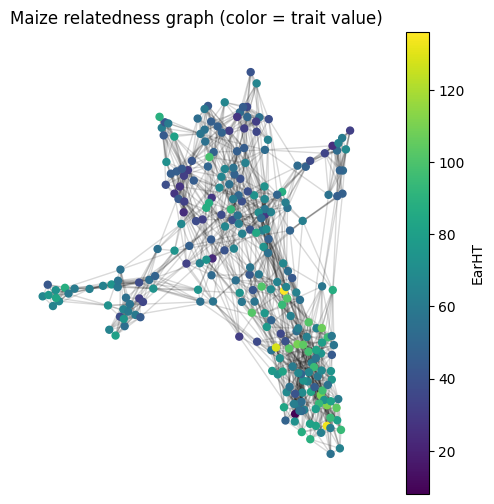

In [53]:
# ============================================================
# Cell (optional but fun): draw a small picture of the relatedness graph
# ============================================================
# This uses a spring layout, where more strongly connected nodes are pulled
# closer together. Color = the trait value, so you can visually check
# whether genetically related lines (nodes close together) tend to have
# similar trait values (similar colors) -- the core assumption behind both
# GBLUP and our GNN.
import networkx as nx

G = nx.Graph()
G.add_nodes_from(range(N))
for s, d, w in zip(edge_src, edge_dst, edge_weight_list):
    G.add_edge(s, d, weight=w)

plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=SEED, weight="weight")
nodes = nx.draw_networkx_nodes(G, pos, node_size=25, node_color=phenotype, cmap="viridis")
nx.draw_networkx_edges(G, pos, alpha=0.15)
plt.colorbar(nodes, label=TARGET_TRAIT)
plt.title("Maize relatedness graph (color = trait value)")
plt.axis("off")
plt.show()


In [54]:
# ============================================================
# Cell: Build the PyG Data object + train/val/test masks
# ============================================================

# It helps optimization a lot to standardize the *target* too (mean 0, std 1),
# then convert predictions back to the original scale only when reporting
# results. We use only the TRAINING individuals to compute this mean/std,
# for the same data-leakage reason as with the PCA above.
y_all = torch.tensor(phenotype, dtype=torch.float32)
y_mean = y_all[train_idx].mean()
y_std  = y_all[train_idx].std()
y_normalized = (y_all - y_mean) / y_std

train_mask = torch.zeros(N, dtype=torch.bool); train_mask[train_idx] = True
val_mask   = torch.zeros(N, dtype=torch.bool); val_mask[val_idx]     = True
test_mask  = torch.zeros(N, dtype=torch.bool); test_mask[test_idx]   = True

data = Data(
    x=torch.tensor(node_features, dtype=torch.float32),  # (N, N_COMPONENTS) node features
    edge_index=edge_index,                                # (2, num_edges) graph structure
    edge_attr=edge_weight,                                # (num_edges,)  edge weights (kinship)
    y=y_normalized,                                        # (N,) standardized trait values
)
data.train_mask, data.val_mask, data.test_mask = train_mask, val_mask, test_mask

print(data)


Data(x=[264, 20], edge_index=[2, 4224], edge_attr=[4224], y=[264], train_mask=[264], val_mask=[264], test_mask=[264])


In [55]:
# ============================================================
# Cell: The GCN model definition
# ============================================================

class GenomicGCN(torch.nn.Module):
    '''A small 2-layer Graph Convolutional Network for predicting a
    continuous trait (regression) for every node (maize line) in the graph.'''

    def __init__(self, in_channels, hidden_channels=32, dropout=0.5):
        super().__init__()
        # First graph-convolution: (num_SNP_PCs) -> (hidden_channels)
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Second graph-convolution: (hidden_channels) -> (hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        # Final plain linear layer that outputs ONE number per node
        # (the predicted trait value) — no graph mixing needed here.
        self.output_layer = torch.nn.Linear(hidden_channels, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight):
        # --- Graph convolution block 1 ---
        h = self.conv1(x, edge_index, edge_weight)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # --- Graph convolution block 2 ---
        h = self.conv2(h, edge_index, edge_weight)
        h = F.relu(h)

        # --- Prediction head ---
        out = self.output_layer(h)      # shape: (N, 1)
        return out.squeeze(-1)          # shape: (N,) -- one value per maize line

model = GenomicGCN(in_channels=node_features.shape[1])
print(model)


GenomicGCN(
  (conv1): GCNConv(20, 32)
  (conv2): GCNConv(32, 32)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [56]:
# ============================================================
# Cell: Training loop with early stopping
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=0.02, weight_decay=1e-3)

MAX_EPOCHS = 500
PATIENCE = 30   # stop if val loss hasn't improved for this many epochs

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0
train_loss_history, val_loss_history = [], []

for epoch in range(MAX_EPOCHS):
    # ---- training step ----
    model.train()
    optimizer.zero_grad()
    predictions = model(data.x, data.edge_index, data.edge_attr)
    train_loss = F.mse_loss(predictions[data.train_mask], data.y[data.train_mask])
    train_loss.backward()
    optimizer.step()

    # ---- validation step (no gradient needed) ----
    model.eval()
    with torch.no_grad():
        predictions = model(data.x, data.edge_index, data.edge_attr)
        val_loss = F.mse_loss(predictions[data.val_mask], data.y[data.val_mask])

    train_loss_history.append(train_loss.item())
    val_loss_history.append(val_loss.item())

    # ---- early stopping bookkeeping ----
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement > PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val loss = {best_val_loss:.4f})")
            break

    if epoch % 25 == 0:
        print(f"epoch {epoch:3d} | train loss {train_loss.item():.4f} | val loss {val_loss.item():.4f}")

# Restore the weights from the best epoch (lowest validation loss), not
# necessarily the very last epoch.
model.load_state_dict(best_model_state)
print("\nTraining finished. Restored the best model (by validation loss).")


epoch   0 | train loss 2.5684 | val loss 1.7334
epoch  25 | train loss 0.6159 | val loss 0.6914
epoch  50 | train loss 0.5419 | val loss 0.6742
epoch  75 | train loss 0.5138 | val loss 0.6721
epoch 100 | train loss 0.4982 | val loss 0.6943
Early stopping at epoch 118 (best val loss = 0.6475)

Training finished. Restored the best model (by validation loss).


In [59]:
def train_model(model, data, optimizer, max_epochs, patience):
    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0
    train_loss_history, val_loss_history = [], []

    for epoch in range(max_epochs):
        # ---- training step ----
        model.train()
        optimizer.zero_grad()
        predictions = model(data.x, data.edge_index, data.edge_attr)
        train_loss = F.mse_loss(predictions[data.train_mask], data.y[data.train_mask])
        train_loss.backward()
        optimizer.step()

        # ---- validation step (no gradient needed) ----
        model.eval()
        with torch.no_grad():
            predictions = model(data.x, data.edge_index, data.edge_attr)
            val_loss = F.mse_loss(predictions[data.val_mask], data.y[data.val_mask])

        train_loss_history.append(train_loss.item())
        val_loss_history.append(val_loss.item())

        # ---- early stopping bookkeeping ----
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement > patience:
                # print(f"Early stopping at epoch {epoch} (best val loss = {best_val_loss:.4f})")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)
    return best_val_loss, train_loss_history, val_loss_history

### Hyperparameter Tuning using Grid Search

Now, I will perform a grid search over a set of hyperparameters to find the best configuration for the `GenomicGCN` model. The hyperparameters to tune are:

*   `hidden_channels`: The number of hidden units in the graph convolutional layers.
*   `dropout`: The dropout probability for regularization.
*   `learning rate (lr)`: The step size for the optimizer.
*   `weight_decay`: The L2 regularization penalty for the optimizer.

In [60]:
import itertools

# Define the hyperparameter grid
hidden_channels_options = [16, 32, 64]
dropout_options = [0.3, 0.5, 0.7]
lr_options = [0.01, 0.005, 0.001]
weight_decay_options = [1e-3, 1e-4]

best_params = None
best_val_loss_overall = float('inf')
results = []

# Iterate through all combinations of hyperparameters
for hidden_channels, dropout, lr, weight_decay in itertools.product(
    hidden_channels_options, dropout_options, lr_options, weight_decay_options
):
    print(f"\nTraining with: hidden_channels={hidden_channels}, dropout={dropout}, lr={lr}, weight_decay={weight_decay}")

    # Initialize model and optimizer for the current combination
    model = GenomicGCN(in_channels=node_features.shape[1], hidden_channels=hidden_channels, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Train the model
    val_loss, _, _ = train_model(model, data, optimizer, MAX_EPOCHS, PATIENCE)

    results.append({
        'hidden_channels': hidden_channels,
        'dropout': dropout,
        'lr': lr,
        'weight_decay': weight_decay,
        'val_loss': val_loss
    })

    if val_loss < best_val_loss_overall:
        best_val_loss_overall = val_loss
        best_params = {
            'hidden_channels': hidden_channels,
            'dropout': dropout,
            'lr': lr,
            'weight_decay': weight_decay
        }

print("\nGrid search complete.")
print(f"Best validation loss: {best_val_loss_overall:.4f}")
print(f"Best parameters: {best_params}")



Training with: hidden_channels=16, dropout=0.3, lr=0.01, weight_decay=0.001

Training with: hidden_channels=16, dropout=0.3, lr=0.01, weight_decay=0.0001

Training with: hidden_channels=16, dropout=0.3, lr=0.005, weight_decay=0.001

Training with: hidden_channels=16, dropout=0.3, lr=0.005, weight_decay=0.0001

Training with: hidden_channels=16, dropout=0.3, lr=0.001, weight_decay=0.001

Training with: hidden_channels=16, dropout=0.3, lr=0.001, weight_decay=0.0001

Training with: hidden_channels=16, dropout=0.5, lr=0.01, weight_decay=0.001

Training with: hidden_channels=16, dropout=0.5, lr=0.01, weight_decay=0.0001

Training with: hidden_channels=16, dropout=0.5, lr=0.005, weight_decay=0.001

Training with: hidden_channels=16, dropout=0.5, lr=0.005, weight_decay=0.0001

Training with: hidden_channels=16, dropout=0.5, lr=0.001, weight_decay=0.001

Training with: hidden_channels=16, dropout=0.5, lr=0.001, weight_decay=0.0001

Training with: hidden_channels=16, dropout=0.7, lr=0.01, weig

### Retrain and Evaluate with Best Parameters

Now, I will re-initialize and train the `GenomicGCN` model using the best hyperparameters found during the grid search. After training, I will evaluate its performance on the test set and visualize the predictions.

In [61]:
print(f"\nRetraining model with best parameters: {best_params}")

# Initialize the model with the best parameters
model = GenomicGCN(
    in_channels=node_features.shape[1],
    hidden_channels=best_params['hidden_channels'],
    dropout=best_params['dropout']
)

# Initialize the optimizer with the best learning rate and weight decay
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

# Train the model with the best parameters
best_val_loss_final, train_loss_history, val_loss_history = train_model(model, data, optimizer, MAX_EPOCHS, PATIENCE)

print("Training with best parameters finished.")


Retraining model with best parameters: {'hidden_channels': 32, 'dropout': 0.5, 'lr': 0.005, 'weight_decay': 0.001}
Training with best parameters finished.


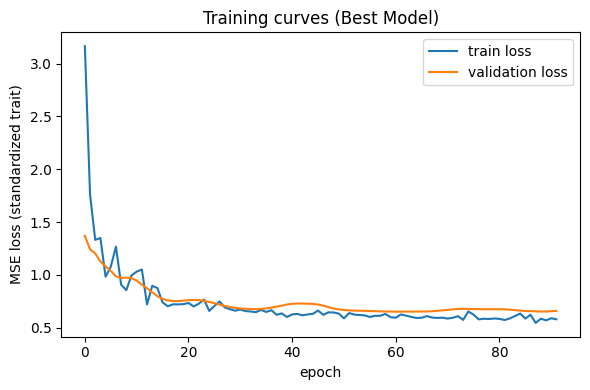

In [62]:
# ============================================================
# Cell: Plot the training curves for the best model
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(train_loss_history, label="train loss")
plt.plot(val_loss_history, label="validation loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss (standardized trait)")
plt.title("Training curves (Best Model)")
plt.legend()
plt.tight_layout()
plt.show()

GCN (tuned) test-set prediction accuracy (Pearson r): 0.353  (p = 0.0238)
GCN (tuned) test-set RMSE: 17.40  (EarHT std. dev. in this panel: 20.45)


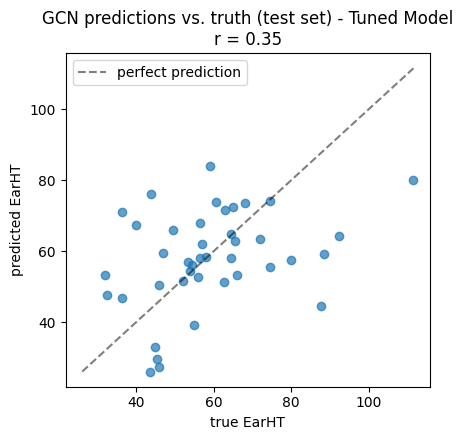

In [63]:
# ============================================================
# Cell: Evaluate the best model on the test set
# ============================================================
model.eval()
with torch.no_grad():
    predictions = model(data.x, data.edge_index, data.edge_attr)

# Convert predictions back from "standardized" units to real trait units
pred_test_real = (predictions[test_mask] * y_std + y_mean).numpy()
true_test_real = y_all[test_mask].numpy()

r_value_tuned, p_value_tuned = pearsonr(pred_test_real, true_test_real)
rmse_tuned = np.sqrt(np.mean((pred_test_real - true_test_real) ** 2))

print(f"GCN (tuned) test-set prediction accuracy (Pearson r): {r_value_tuned:.3f}  (p = {p_value_tuned:.4f})")
print(f"GCN (tuned) test-set RMSE: {rmse_tuned:.2f}  ({TARGET_TRAIT} std. dev. in this panel: {phenotype.std():.2f})")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(true_test_real, pred_test_real, alpha=0.7)
lims = [min(true_test_real.min(), pred_test_real.min()), max(true_test_real.max(), pred_test_real.max())]
plt.plot(lims, lims, "k--", alpha=0.5, label="perfect prediction")
plt.xlabel(f"true {TARGET_TRAIT}")
plt.ylabel(f"predicted {TARGET_TRAIT}")
plt.title(f"GCN predictions vs. truth (test set) - Tuned Model\nr = {r_value_tuned:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# Compare with baseline
print(f"Ridge regression (no graph) test accuracy (r): {ridge_r:.3f}")
print(f"Ridge regression (no graph) test RMSE:        {ridge_rmse:.2f}")
print()
print(f"GCN (original)   test accuracy (r): {r_value:.3f}")
print(f"GCN (original)   test RMSE:        {rmse:.2f}")
print()
print(f"GCN (tuned)      test accuracy (r): {r_value_tuned:.3f}")
print(f"GCN (tuned)      test RMSE:        {rmse_tuned:.2f}")

Ridge regression (no graph) test accuracy (r): 0.348
Ridge regression (no graph) test RMSE:        16.04

GCN (original)   test accuracy (r): 0.396
GCN (original)   test RMSE:        16.73

GCN (tuned)      test accuracy (r): 0.353
GCN (tuned)      test RMSE:        17.40


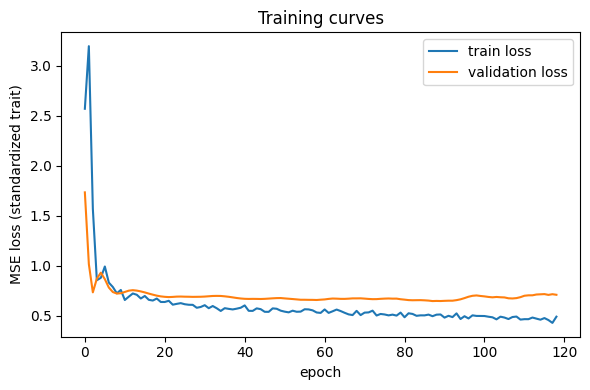

In [57]:
# ============================================================
# Cell: Plot the training curves
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(train_loss_history, label="train loss")
plt.plot(val_loss_history, label="validation loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss (standardized trait)")
plt.title("Training curves")
plt.legend()
plt.tight_layout()
plt.show()

GCN test-set prediction accuracy (Pearson r): 0.396  (p = 0.0103)
GCN test-set RMSE: 16.73  (EarHT std. dev. in this panel: 20.45)


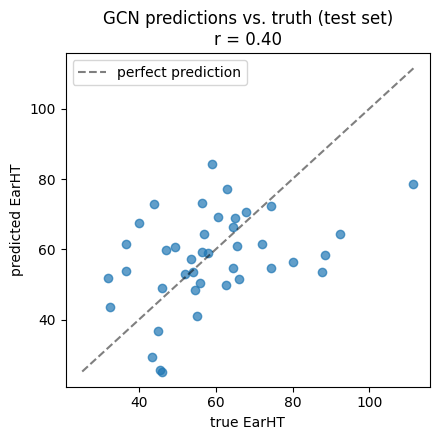

In [58]:
# ============================================================
# Cell: Evaluate on the test set
# ============================================================
model.eval()
with torch.no_grad():
    predictions = model(data.x, data.edge_index, data.edge_attr)

# Convert predictions back from "standardized" units to real trait units
# (undo the normalization from Section 6) so the numbers are interpretable.
pred_test_real = (predictions[test_mask] * y_std + y_mean).numpy()
true_test_real = y_all[test_mask].numpy()

r_value, p_value = pearsonr(pred_test_real, true_test_real)
rmse = np.sqrt(np.mean((pred_test_real - true_test_real) ** 2))

print(f"GCN test-set prediction accuracy (Pearson r): {r_value:.3f}  (p = {p_value:.4f})")
print(f"GCN test-set RMSE: {rmse:.2f}  ({TARGET_TRAIT} std. dev. in this panel: {phenotype.std():.2f})")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(true_test_real, pred_test_real, alpha=0.7)
lims = [min(true_test_real.min(), pred_test_real.min()), max(true_test_real.max(), pred_test_real.max())]
plt.plot(lims, lims, "k--", alpha=0.5, label="perfect prediction")
plt.xlabel(f"true {TARGET_TRAIT}")
plt.ylabel(f"predicted {TARGET_TRAIT}")
plt.title(f"GCN predictions vs. truth (test set)\nr = {r_value:.2f}")
plt.legend()
plt.tight_layout()
plt.show()


In [50]:
# ============================================================
# Cell: Ridge regression baseline (no graph, same features)
# ============================================================
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(node_features[train_idx], phenotype[train_idx])
ridge_pred_test = ridge_model.predict(node_features[test_idx])

ridge_r, _ = pearsonr(ridge_pred_test, phenotype[test_idx])
ridge_rmse = np.sqrt(np.mean((ridge_pred_test - phenotype[test_idx]) ** 2))

print(f"Ridge regression (no graph) test accuracy (r): {ridge_r:.3f}")
print(f"Ridge regression (no graph) test RMSE:        {ridge_rmse:.2f}")
print()
print(f"GCN (with kinship graph)   test accuracy (r): {r_value:.3f}")
print(f"GCN (with kinship graph)   test RMSE:        {rmse:.2f}")


Ridge regression (no graph) test accuracy (r): 0.348
Ridge regression (no graph) test RMSE:        16.04

GCN (with kinship graph)   test accuracy (r): 0.347
GCN (with kinship graph)   test RMSE:        17.27


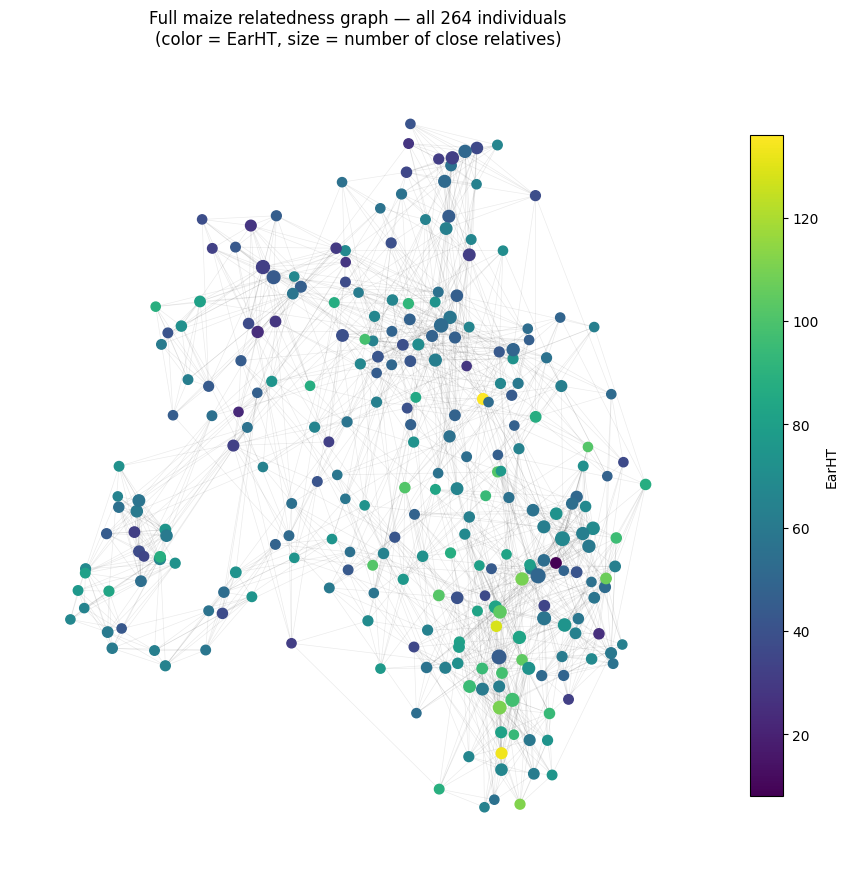

In [30]:
# ============================================================
# Cell: Full relatedness graph, all 264 individuals, cleaner rendering
# ============================================================
import networkx as nx

G = nx.Graph()
G.add_nodes_from(range(N))
for s, d, w in zip(edge_src, edge_dst, edge_weight_list):
    G.add_edge(s, d, weight=w)

plt.figure(figsize=(9, 9))  # bigger canvas = less overlap

# Layout: nodes pulled together by kinship strength
pos = nx.spring_layout(G, seed=SEED, weight="weight", k=0.3)

# Size nodes a bit by how many relatives they have (degree) -- purely cosmetic,
# helps you visually spot "hub" lines with many close relatives in the panel.
degrees = dict(G.degree())
node_sizes = [20 + 3 * degrees[n] for n in G.nodes()]

nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=phenotype,     # color = trait value (EarHT)
    cmap="viridis",
)
nx.draw_networkx_edges(G, pos, alpha=0.08, width=0.5)  # thinner, fainter edges

plt.colorbar(nodes, label=TARGET_TRAIT, shrink=0.8)
plt.title(f"Full maize relatedness graph — all {N} individuals\n"
          f"(color = {TARGET_TRAIT}, size = number of close relatives)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# Cell: Full table of predicted vs. true phenotype, per maize line
# ============================================================
model.eval()
with torch.no_grad():
    all_preds_std = model(data.x, data.edge_index, data.edge_attr)
all_preds_real = (all_preds_std * y_std + y_mean).numpy()

split_label = np.array(["train"] * N)
split_label[val_idx] = "val"
split_label[test_idx] = "test"

results_df = pd.DataFrame({
    "taxa": common_lines,
    "split": split_label,
    f"true_{TARGET_TRAIT}": phenotype,
    f"predicted_{TARGET_TRAIT}": all_preds_real,
})
results_df["abs_error"] = (results_df[f"true_{TARGET_TRAIT}"] - results_df[f"predicted_{TARGET_TRAIT}"]).abs()

# Sort by prediction error so you can see the best- and worst-predicted lines
results_df.sort_values("abs_error").reset_index(drop=True)

,taxa,split,true_EarHT,predicted_EarHT,abs_error
0,HY,train,56.500000,56.561493,0.061493
1,KY228,train,58.380001,58.105061,0.274940
2,A634,test,54.000000,54.313633,0.313633
3,NC314,test,58.000000,58.328506,0.328506
4,CI64,test,64.500000,64.911598,0.411598
...,...,...,...,...,...
259,CML258,train,133.000000,89.294868,43.705132
260,GT112,train,136.000000,90.318634,45.681366
261,NC238,train,43.000000,89.116005,46.116005
262,NC304,train,8.000000,59.962051,51.962051


In [66]:
# ============================================================
# Cell: Simple SNP-phenotype association scan (a "mini-GWAS")
# ============================================================
from scipy.stats import pearsonr

snp_info = pd.read_csv(os.path.join(DATA_DIR, "mdp_SNP_information.txt"), sep="\t").set_index("SNP")

results = []
for snp_name in geno_df.columns:
    snp_vals = geno_df.loc[common_lines, snp_name].values.astype(np.float32)
    if snp_vals.std() == 0:   # skip SNPs with no variation in this subset
        continue
    r, p = pearsonr(snp_vals, phenotype)
    results.append((snp_name, r, p))

gwas_df = pd.DataFrame(results, columns=["SNP", "r", "p_value"]).set_index("SNP")
gwas_df = gwas_df.join(snp_info)  # attach Chromosome + Position
top_snps = gwas_df.sort_values("p_value").head(20)
top_snps

,r,p_value,Chromosome,Position
SNP,,,,
PZA03188.4,-0.328635,4.578632e-08,1,280719882
PZB00801.1,0.318510,1.229874e-07,1,174183331
PZD00032.1,0.312297,2.215390e-07,10,30830484
PZA03647.3,0.301426,6.009360e-07,3,185318086
PZA03194.1,0.296104,9.653293e-07,1,212244425
PZA03537.1,0.290836,1.528868e-06,8,171581059
PZA03648.2,-0.288349,1.893582e-06,3,185317151
PZB00811.1,-0.282742,3.044329e-06,8,160536300
PZA03240.2,0.275158,5.693287e-06,1,90772275


In [67]:
pc_importance = model.conv1.lin.weight.detach().numpy()  # shape: (hidden, n_components)
pc_importance = np.abs(pc_importance).mean(axis=0)        # average absolute importance per PC
snp_importance = np.abs(pca.components_.T @ pc_importance)  # project back to SNP space
snp_importance_df = pd.DataFrame({"SNP": geno_df.columns, "importance": snp_importance}).set_index("SNP")
snp_importance_df.join(snp_info).sort_values("importance", ascending=False).head(20)

,importance,Chromosome,Position
SNP,,,
PZB00080.2,0.049301,9,130608245
PZB00228.5,0.046743,3,150830673
PZB02502.2,0.046514,1,291032289
PZB01479.1,0.046143,5,11738957
PZB01107.6,0.044899,8,162012097
PZB00648.4,0.044351,1,17595070
PZA03550.2,0.042876,6,137326008
PZB02523.1,0.042194,2,32949215
PZB01285.1,0.041977,2,145725068


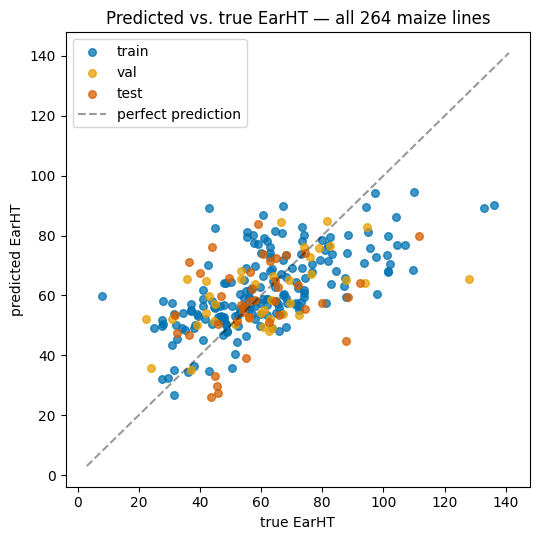

In [68]:
# ============================================================
# Cell: Predicted vs. true phenotype, all individuals, colored by split
# ============================================================
# Fixed, colorblind-safe categorical colors (Okabe-Ito palette) -- one hue per
# split, assigned in a fixed order so "train" is always the same color no
# matter how you filter or re-run this.
SPLIT_COLORS = {"train": "#0072B2", "val": "#E69F00", "test": "#D55E00"}

plt.figure(figsize=(5.5, 5.5))
for split_name, color in SPLIT_COLORS.items():
    mask = results_df["split"] == split_name
    plt.scatter(
        results_df.loc[mask, f"true_{TARGET_TRAIT}"],
        results_df.loc[mask, f"predicted_{TARGET_TRAIT}"],
        label=split_name, color=color, alpha=0.75, s=30,
    )

lims = [phenotype.min() - 5, phenotype.max() + 5]
plt.plot(lims, lims, "k--", alpha=0.4, label="perfect prediction")
plt.xlabel(f"true {TARGET_TRAIT}")
plt.ylabel(f"predicted {TARGET_TRAIT}")
plt.title(f"Predicted vs. true {TARGET_TRAIT} — all {N} maize lines")
plt.legend()
plt.tight_layout()
plt.show()

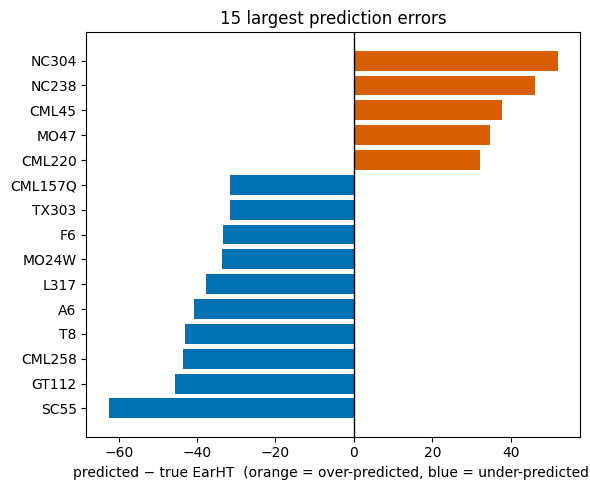

In [69]:
# ============================================================
# Cell: Top mispredicted lines (signed error, diverging color)
# ============================================================
results_df["signed_error"] = results_df[f"predicted_{TARGET_TRAIT}"] - results_df[f"true_{TARGET_TRAIT}"]
top_errors = results_df.reindex(results_df["signed_error"].abs().sort_values(ascending=False).index).head(15)
top_errors = top_errors.sort_values("signed_error")

colors = ["#D55E00" if v > 0 else "#0072B2" for v in top_errors["signed_error"]]  # warm=over, cool=under
plt.figure(figsize=(6, 5))
plt.barh(top_errors["taxa"], top_errors["signed_error"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel(f"predicted − true {TARGET_TRAIT}  (orange = over-predicted, blue = under-predicted)")
plt.title("15 largest prediction errors")
plt.tight_layout()
plt.show()

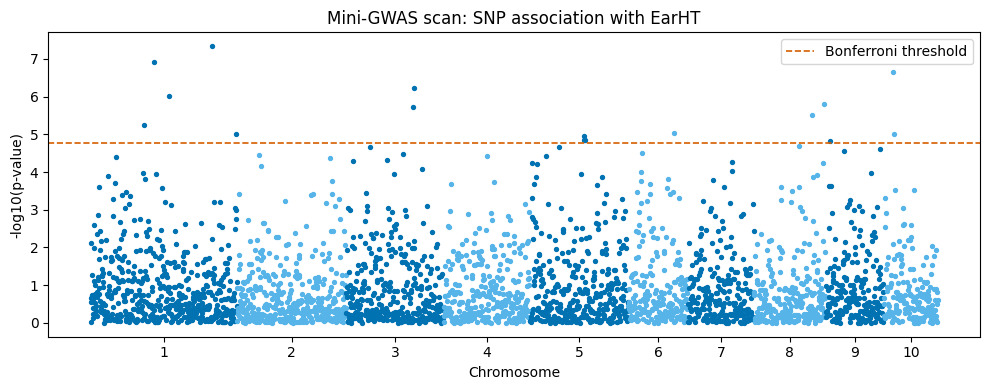

In [70]:
# ============================================================
# Cell: Manhattan plot of the mini-GWAS scan (gwas_df from the previous step)
# ============================================================
gwas_plot = gwas_df.dropna(subset=["Chromosome", "Position"]).copy()
gwas_plot["neg_log10_p"] = -np.log10(gwas_plot["p_value"])
gwas_plot = gwas_plot.sort_values(["Chromosome", "Position"])

# Alternate two fixed colors by chromosome -- the standard Manhattan-plot
# convention, so adjacent chromosomes are visually distinguishable without
# needing 10 different hues.
CHR_COLORS = ["#0072B2", "#56B4E9"]
chrom_ids = sorted(gwas_plot["Chromosome"].unique())

plt.figure(figsize=(10, 4))
x_offset = 0
tick_positions, tick_labels = [], []
for i, chrom in enumerate(chrom_ids):
    sub = gwas_plot[gwas_plot["Chromosome"] == chrom]
    xs = x_offset + np.arange(len(sub))
    plt.scatter(xs, sub["neg_log10_p"], color=CHR_COLORS[i % 2], s=8)
    tick_positions.append(x_offset + len(sub) / 2)
    tick_labels.append(str(chrom))
    x_offset += len(sub)

# Bonferroni significance line: 0.05 / number of SNPs tested
bonferroni = -np.log10(0.05 / len(gwas_plot))
plt.axhline(bonferroni, color="#D55E00", linestyle="--", linewidth=1.2, label="Bonferroni threshold")

plt.xticks(tick_positions, tick_labels)
plt.xlabel("Chromosome")
plt.ylabel("-log10(p-value)")
plt.title(f"Mini-GWAS scan: SNP association with {TARGET_TRAIT}")
plt.legend()
plt.tight_layout()
plt.show()

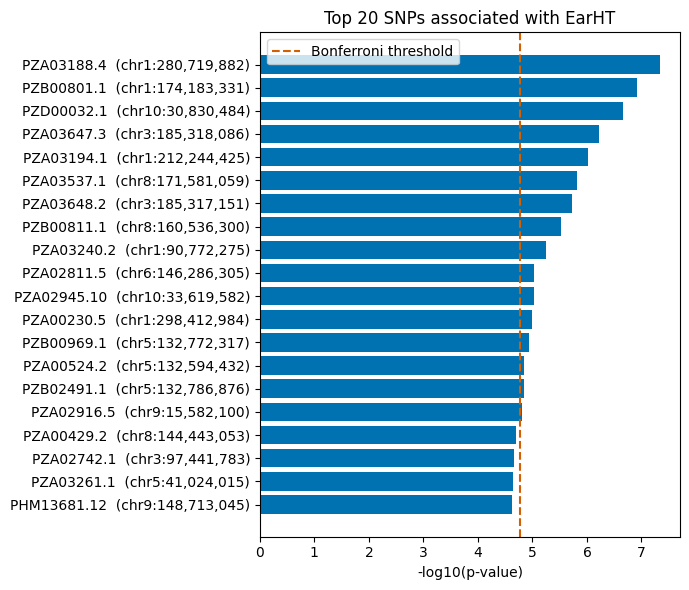

In [71]:
# ============================================================
# Cell: Top 20 SNP-phenotype associations, ranked
# ============================================================
top20 = gwas_df.sort_values("p_value").head(20).copy()
top20["neg_log10_p"] = -np.log10(top20["p_value"])
top20 = top20.sort_values("neg_log10_p")  # smallest at bottom, biggest at top

labels = [f"{snp}  (chr{int(row.Chromosome)}:{int(row.Position):,})" for snp, row in top20.iterrows()]

plt.figure(figsize=(7, 6))
plt.barh(labels, top20["neg_log10_p"], color="#0072B2")
plt.axvline(bonferroni, color="#D55E00", linestyle="--", label="Bonferroni threshold")
plt.xlabel("-log10(p-value)")
plt.title(f"Top 20 SNPs associated with {TARGET_TRAIT}")
plt.legend()
plt.tight_layout()
plt.show()